# Working-Memory Task Schematic

**A**, Trial structure with simulated durations (`dt = 20` ms).
**B**, Same example trial as supervised RNN signals: fixation step traces plus
32-unit population heatmaps (HSV orientation × activity).
**C**, Manim animation of hidden-state PCA from stimulus onset through the last
delay step (Yang checkpoint; HSV = target angle).


saved c:\Users\Bob Rice\Documents\Obsidian Vault\Dissertation\working-memory-rnn\outputs\figures\schematics\working_memory_task_schematic.png
c:\Users\Bob Rice\Documents\Obsidian Vault\Dissertation\working-memory-rnn\outputs\figures\schematics\working_memory_task_schematic.png


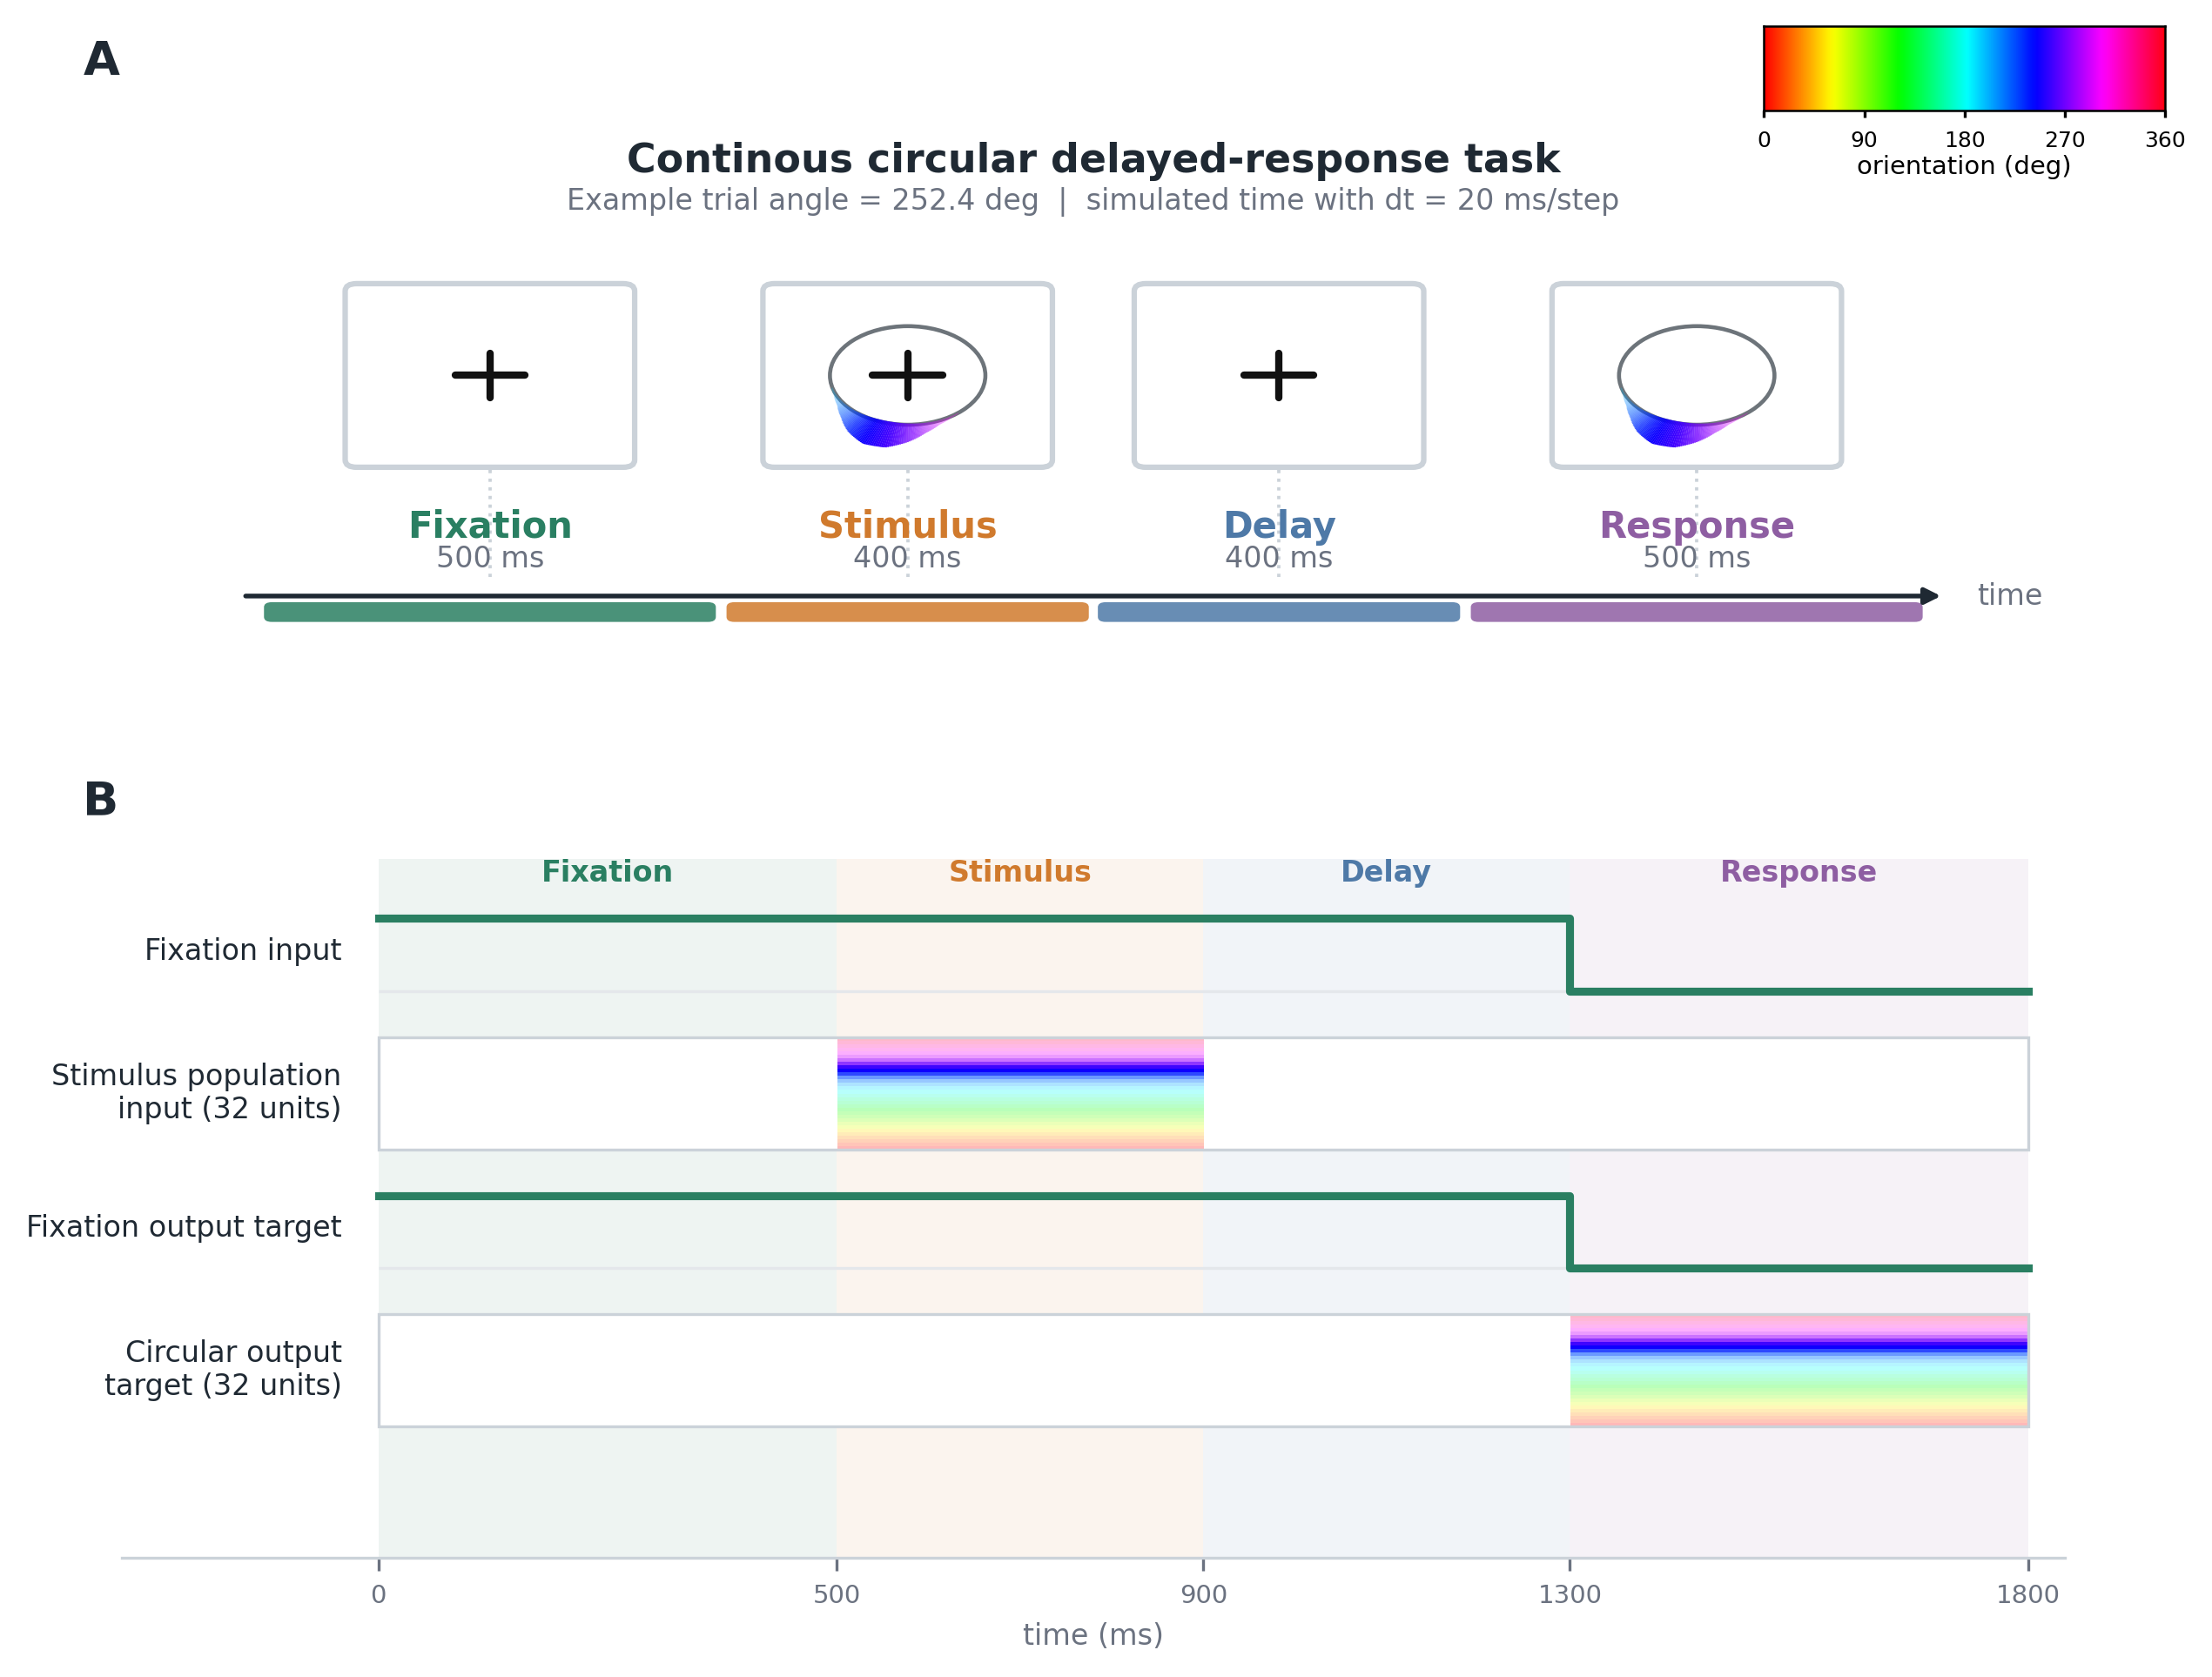

In [ ]:
import json
from pathlib import Path
import sys

import numpy as np
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.path import Path as MplPath

cwd = Path.cwd()
REPO = cwd.parent if cwd.name == "notebooks" else cwd
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))
from wm_rnn.tuned_task import TunedDelayTaskConfig, generate_tuned_delay_batch

OUTDIR = REPO / "outputs" / "figures" / "schematics"
OUTDIR.mkdir(parents=True, exist_ok=True)

PRE_CUE, CUE, DELAY, RESPONSE = 25, 20, 20, 25
DT_MS = 20.0
N_UNITS = 32
TUNING_KAPPA = 8.0
TRIAL_SEED = 20260721
TRIAL_INDEX = 0
BOX_SIZE = 1.45
CROSS_SIZE = 0.18
CROSS_LW = 2.0
CROSS_COLOR = "#111111"

task_config = TunedDelayTaskConfig(
    n_tuned_units=N_UNITS,
    tuning_kappa=TUNING_KAPPA,
    pre_cue_steps=PRE_CUE,
    cue_steps=CUE,
    delay_steps=DELAY,
    response_steps=RESPONSE,
    batch_size=8,
    seed=TRIAL_SEED,
    fixation_gated=True,
)
batch = generate_tuned_delay_batch(task_config)

# Full trial arrays for Panel B (one example trial).
trial_inputs = batch.inputs[:, TRIAL_INDEX, :].copy()
trial_targets = batch.targets[:, TRIAL_INDEX, :].copy()
preferred = batch.preferred_angles.copy()
trial_angle = float(batch.angles[TRIAL_INDEX])

cue_slice = batch.phase_index["cue"]
resp_slice = batch.phase_index["response"]
stimulus_input = trial_inputs[cue_slice.start + (cue_slice.stop - cue_slice.start) // 2, :N_UNITS]
response_target = trial_targets[resp_slice.start + (resp_slice.stop - resp_slice.start) // 2, :N_UNITS]

COLORS = {
    "ink": "#1F2933",
    "muted": "#6B7280",
    "border": "#CBD2D9",
    "fixation": "#2A7F62",
    "stimulus": "#D07A2D",
    "delay": "#4E79A7",
    "response": "#8E5EA2",
    "screen": "#FFFFFF",
    "grid": "#E4E7EB",
}

EPOCHS = [
    {"name": "Fixation", "steps": PRE_CUE, "ms": PRE_CUE * DT_MS, "color": COLORS["fixation"]},
    {"name": "Stimulus", "steps": CUE, "ms": CUE * DT_MS, "color": COLORS["stimulus"]},
    {"name": "Delay", "steps": DELAY, "ms": DELAY * DT_MS, "color": COLORS["delay"]},
    {"name": "Response", "steps": RESPONSE, "ms": RESPONSE * DT_MS, "color": COLORS["response"]},
]
# Panel B uses real step index as x in ms.
total_steps = PRE_CUE + CUE + DELAY + RESPONSE
time_ms = np.arange(total_steps) * DT_MS
T_MS = total_steps * DT_MS

# Epoch boundaries in ms for shading / proportional Panel A.
epoch_bounds_ms = [0.0]
for epoch in EPOCHS:
    epoch["t0"] = epoch_bounds_ms[-1]
    epoch["t1"] = epoch["t0"] + epoch["ms"]
    epoch_bounds_ms.append(epoch["t1"])

HSV = plt.get_cmap("hsv")


def angle_to_rgb(angle_rad: float):
    return HSV(float(angle_rad % (2.0 * np.pi)) / (2.0 * np.pi))


def draw_screen_frame(ax, center, size=BOX_SIZE):
    x, y = center
    half = size / 2
    ax.add_patch(
        patches.FancyBboxPatch(
            (x - half, y - half),
            size,
            size,
            boxstyle="round,pad=0.02,rounding_size=0.06",
            facecolor=COLORS["screen"],
            edgecolor=COLORS["border"],
            linewidth=1.5,
            zorder=2,
        )
    )


def draw_fixation_cross(ax, center):
    x, y = center
    ax.plot(
        [x - CROSS_SIZE, x + CROSS_SIZE],
        [y, y],
        color=CROSS_COLOR,
        lw=CROSS_LW,
        zorder=6,
        solid_capstyle="round",
    )
    ax.plot(
        [x, x],
        [y - CROSS_SIZE, y + CROSS_SIZE],
        color=CROSS_COLOR,
        lw=CROSS_LW,
        zorder=6,
        solid_capstyle="round",
    )


def smooth_activity_on_circle(activity, n_samples=360):
    activity = np.asarray(activity, dtype=float)
    amp = activity / max(float(activity.max()), 1e-8)
    x = np.concatenate([preferred, preferred[:1] + 2 * np.pi])
    y = np.concatenate([amp, amp[:1]])
    theta = np.linspace(0.0, 2 * np.pi, n_samples, endpoint=False)
    return theta, np.interp(theta, x, y)


def draw_orientation_ribbon(ax, center, activity, radius=0.40, max_width=0.20):
    x, y = center
    theta, amp = smooth_activity_on_circle(activity)
    ax.add_patch(
        patches.Circle(
            (x, y),
            radius,
            fill=False,
            edgecolor=COLORS["ink"],
            linewidth=1.1,
            zorder=3,
            alpha=0.65,
        )
    )
    n = len(theta)
    dtheta = (2 * np.pi) / n
    for i in range(n):
        a = float(amp[i])
        if a < 0.03:
            continue
        th0 = theta[i] - 0.55 * dtheta
        th1 = theta[i] + 0.55 * dtheta
        r_out = radius + max_width * a
        r_in = radius - 0.015 * a
        wedge_theta = np.linspace(th0, th1, 6)
        outer = np.column_stack(
            [x + r_out * np.cos(wedge_theta), y + r_out * np.sin(wedge_theta)]
        )
        inner = np.column_stack(
            [x + r_in * np.cos(wedge_theta[::-1]), y + r_in * np.sin(wedge_theta[::-1])]
        )
        verts = np.vstack([outer, inner, outer[:1]])
        codes = [MplPath.MOVETO] + [MplPath.LINETO] * (len(verts) - 2) + [MplPath.CLOSEPOLY]
        ax.add_patch(
            patches.PathPatch(
                MplPath(verts, codes),
                facecolor=angle_to_rgb(theta[i]),
                edgecolor="none",
                alpha=0.25 + 0.75 * a,
                zorder=4,
            )
        )


def draw_epoch_screen(ax, center, epoch_name):
    draw_screen_frame(ax, center)
    if epoch_name == "Fixation":
        draw_fixation_cross(ax, center)
    elif epoch_name == "Stimulus":
        draw_orientation_ribbon(ax, center, stimulus_input)
        draw_fixation_cross(ax, center)
    elif epoch_name == "Delay":
        draw_fixation_cross(ax, center)
    elif epoch_name == "Response":
        draw_orientation_ribbon(ax, center, response_target)


def add_panel_label(ax, label):
    ax.text(
        -0.02,
        1.05,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color=COLORS["ink"],
    )


def shade_epochs(ax, ymin, ymax):
    for epoch in EPOCHS:
        ax.axvspan(epoch["t0"], epoch["t1"], color=epoch["color"], alpha=0.08, lw=0, zorder=0)
        ax.text(
            0.5 * (epoch["t0"] + epoch["t1"]),
            ymax,
            epoch["name"],
            ha="center",
            va="top",
            fontsize=8,
            fontweight="bold",
            color=epoch["color"],
            zorder=1,
        )


def plot_fixation_step(ax, y0, height, values, color, label):
    # Step plot in data coordinates within a reserved vertical band.
    ys = y0 + height * np.asarray(values, dtype=float)
    # Stairs: hold value across each dt bin.
    xs = np.concatenate([time_ms, [T_MS]])
    ys_step = np.concatenate([ys, ys[-1:]])
    ax.hlines(y0, 0.0, T_MS, color=COLORS["grid"], lw=0.8, zorder=1)
    ax.step(xs, ys_step, where="post", color=color, lw=2.2, zorder=3)
    ax.text(-40, y0 + 0.55 * height, label, ha="right", va="center", color=COLORS["ink"], fontsize=8)


def population_heatmap_rgba(activity_over_time: np.ndarray, alpha_floor: float = 0.28) -> np.ndarray:
    """Full HSV orientation colours for all units; opacity scales with activity.

    During active time bins (any unit above a small threshold), every preferred-
    angle hue remains visible. Opacity is alpha_floor + (1 - alpha_floor) * amp
    so the bump peak is solid while off-peak units stay faintly coloured.
    Silent time bins stay fully transparent.
    """
    act = np.asarray(activity_over_time, dtype=float)
    amp = act / max(float(act.max()), 1e-8)
    rgba = np.zeros((act.shape[0], act.shape[1], 4), dtype=float)
    active_cols = amp.max(axis=0) > 1e-3
    for i, pref in enumerate(preferred):
        rgb = angle_to_rgb(float(pref))[:3]
        rgba[i, :, :3] = rgb
        rgba[i, active_cols, 3] = alpha_floor + (1.0 - alpha_floor) * amp[i, active_cols]
    return rgba


def plot_population_heatmap(ax, y0, height, activity_over_time, label):
    ax.add_patch(
        patches.Rectangle(
            (0.0, y0), T_MS, height,
            facecolor="white", edgecolor="none", zorder=1,
        )
    )
    rgba = population_heatmap_rgba(activity_over_time)
    ax.imshow(
        rgba,
        aspect="auto",
        origin="lower",
        extent=[0.0, T_MS, y0, y0 + height],
        interpolation="nearest",
        zorder=2,
    )
    ax.add_patch(
        patches.Rectangle(
            (0.0, y0),
            T_MS,
            height,
            fill=False,
            edgecolor=COLORS["border"],
            linewidth=0.8,
            zorder=3,
        )
    )
    ax.text(-40, y0 + 0.5 * height, label, ha="right", va="center", color=COLORS["ink"], fontsize=8)


# ---------------- figure ----------------
fig = plt.figure(figsize=(9.6, 7.2), facecolor="white")
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.35], hspace=0.38)

# Panel A
ax_a = fig.add_subplot(gs[0, 0])
add_panel_label(ax_a, "A")
ax_a.set_xlim(0, 10)
ax_a.set_ylim(0, 4.2)
ax_a.axis("off")

ax_a.text(
    5.0,
    3.95,
    "Continous circular delayed-response task",
    ha="center",
    va="top",
    fontsize=11,
    fontweight="bold",
    color=COLORS["ink"],
)
ax_a.text(
    5.0,
    3.58,
    f"Example trial angle = {np.degrees(trial_angle):.1f} deg  |  "
    f"simulated time with dt = {DT_MS:.0f} ms/step",
    ha="center",
    va="top",
    fontsize=8,
    color=COLORS["muted"],
)

usable_left, usable_right = 0.7, 9.3
span = usable_right - usable_left
screen_centers = []
for epoch in EPOCHS:
    mid = usable_left + span * (0.5 * (epoch["t0"] + epoch["t1"]) / T_MS)
    screen_centers.append((mid, 2.05))

for epoch, center in zip(EPOCHS, screen_centers):
    draw_epoch_screen(ax_a, center, epoch["name"])
    ax_a.text(
        center[0],
        0.82,
        epoch["name"],
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=epoch["color"],
    )
    ax_a.text(
        center[0],
        0.56,
        f"{epoch['ms']:.0f} ms",
        ha="center",
        va="center",
        fontsize=8,
        color=COLORS["muted"],
    )

y_line = 0.26
ax_a.annotate(
    "",
    xy=(9.4, y_line),
    xytext=(0.6, y_line),
    arrowprops={"arrowstyle": "-|>", "lw": 1.3, "color": COLORS["ink"]},
)
ax_a.text(9.55, y_line, "time", ha="left", va="center", color=COLORS["muted"], fontsize=8)

for epoch, center in zip(EPOCHS, screen_centers):
    width = max(0.8, 8.3 * (epoch["t1"] - epoch["t0"]) / T_MS)
    ax_a.add_patch(
        patches.FancyBboxPatch(
            (center[0] - width / 2, 0.06),
            width,
            0.14,
            boxstyle="round,pad=0.01,rounding_size=0.04",
            facecolor=epoch["color"],
            edgecolor="none",
            alpha=0.85,
            zorder=2,
        )
    )
    ax_a.plot([center[0], center[0]], [1.28, 0.38], color=COLORS["border"], lw=0.9, ls=":", zorder=1)

legend_ax = fig.add_axes([0.78, 0.88, 0.16, 0.045])
legend_theta = np.linspace(0, 2 * np.pi, 256)
legend_rgb = np.array([angle_to_rgb(th)[:3] for th in legend_theta])[None, :, :]
legend_ax.imshow(legend_rgb, aspect="auto", extent=[0, 360, 0, 1])
legend_ax.set_yticks([])
legend_ax.set_xticks([0, 90, 180, 270, 360])
legend_ax.tick_params(labelsize=6, length=2)
legend_ax.set_xlabel("orientation (deg)", fontsize=7, labelpad=1)
for spine in legend_ax.spines.values():
    spine.set_linewidth(0.6)

# Panel B
ax_b = fig.add_subplot(gs[1, 0])
add_panel_label(ax_b, "B")
ymax = 5.35
shade_epochs(ax_b, 0.0, ymax)

fix_in = trial_inputs[:, -1]
fix_out = trial_targets[:, -1]
circ_in = trial_inputs[:, :N_UNITS].T  # units x time
circ_out = trial_targets[:, :N_UNITS].T

plot_fixation_step(ax_b, 4.35, 0.55, fix_in, COLORS["fixation"], "Fixation input")
plot_population_heatmap(ax_b, 3.15, 0.85, circ_in, "Stimulus population\ninput (32 units)")
plot_fixation_step(ax_b, 2.25, 0.55, fix_out, COLORS["fixation"], "Fixation output")
plot_population_heatmap(ax_b, 1.05, 0.85, circ_out, "Circular output\ntarget (32 units)")

ax_b.set_xlim(-280, T_MS + 40)
ax_b.set_ylim(0.05, ymax)
ax_b.set_yticks([])
ax_b.set_xticks([epoch["t0"] for epoch in EPOCHS] + [T_MS])
ax_b.set_xticklabels([f"{v:.0f}" for v in ([epoch["t0"] for epoch in EPOCHS] + [T_MS])])
ax_b.set_xlabel("time (ms)", fontsize=8, color=COLORS["muted"])
ax_b.tick_params(axis="x", labelsize=7, colors=COLORS["muted"])
for spine in ["left", "right", "top"]:
    ax_b.spines[spine].set_visible(False)
ax_b.spines["bottom"].set_color(COLORS["border"])


png_path = OUTDIR / "working_memory_task_schematic.png"
pdf_path = OUTDIR / "working_memory_task_schematic.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
plt.close(fig)
print("saved", png_path)

png_path = OUTDIR / "working_memory_task_schematic.png"
pdf_path = OUTDIR / "working_memory_task_schematic.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
plt.close(fig)
print(png_path)
from IPython.display import Image, display
display(Image(filename=str(png_path)))


## C. Hidden-state PCA: stimulus → late delay

Animate the Yang model's hidden activity in a 2D PCA plane fitted on the
stimulus-through-delay window (`cue` start → `delay` stop; 20 + 20 steps at
`dt = 20` ms). Trajectories are linearly interpolated between RNN steps for
smooth motion. Trials are coloured by target angle (same HSV convention as
Panel A/B).

- Model forward pass uses **CUDA** when available.
- ManimGL draws via OpenGL (GPU). Master export is MP4; a compact palette GIF
  is derived with ffmpeg for easy inline display.

Set `RENDER_PCA_ANIM = True` to rebuild arrays and re-render; otherwise the
existing schematic MP4/GIF is shown if present.


In [ ]:
from __future__ import annotations

import subprocess
import sys
from dataclasses import replace
from pathlib import Path
from textwrap import dedent

import numpy as np
import torch
import yaml
from IPython.display import Video, Image, display
from sklearn.decomposition import PCA

# Toggle: True rebuilds arrays + Manim MP4/GIF. False only displays existing files.
RENDER_PCA_ANIM = False

REPO = Path("..").resolve()
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from wm_rnn.training_utils import (  # noqa: E402
    batch_to_tensors,
    fresh_model,
    generate_batch_for_task,
    task_config_from_dict,
)

OUTDIR = REPO / "outputs" / "figures" / "schematics"
TMP = REPO / "tmp"
OUTDIR.mkdir(parents=True, exist_ok=True)
TMP.mkdir(parents=True, exist_ok=True)

N_TRIALS = 256
DT_MS = 20.0
INTERP_PER_STEP = 12  # frames between successive RNN steps (smoothness)
FPS = 20              # playback fps (lower + more interp = slower/smoother)
HOLD_START_S = 0.6
HOLD_END_S = 1.8
DOT_RADIUS = 0.038
FILE_NAME = "yang_stimulus_to_delay_pca"
ARRAYS_PATH = OUTDIR / "yang_stimulus_to_delay_pca_trajectories.npz"
MP4_PATH = OUTDIR / f"{FILE_NAME}.mp4"
GIF_PATH = OUTDIR / f"{FILE_NAME}.gif"
SCENE_PATH = TMP / "stimulus_to_delay_pca_scene.py"


def pick_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def interpolate_trajectories(traj, time_ms, interp_per_step):
    if interp_per_step <= 1 or traj.shape[0] < 2:
        return traj, time_ms
    segments, times = [], []
    for t in range(traj.shape[0] - 1):
        for k in range(interp_per_step):
            alpha = k / interp_per_step
            segments.append((1.0 - alpha) * traj[t] + alpha * traj[t + 1])
            times.append((1.0 - alpha) * time_ms[t] + alpha * time_ms[t + 1])
    segments.append(traj[-1])
    times.append(time_ms[-1])
    return np.stack(segments, axis=0), np.asarray(times, dtype=np.float64)


def build_trajectory_arrays() -> dict:
    config = yaml.safe_load(
        (REPO / "configs/yang_fixation_circular_working_memory.yaml").read_text(encoding="utf-8")
    )
    ckpt = (
        REPO
        / "outputs/yang_fixation_circular_working_memory/checkpoints"
        / "yang_fixation_circular_working_memory.pt"
    )
    device = pick_device()
    print("device", device)
    model = fresh_model(config, device)
    model.load_state_dict(torch.load(ckpt, map_location=device)["model_state"])
    model.eval()

    task = task_config_from_dict(config, seed_offset=92000, batch_size=N_TRIALS)
    task = replace(
        task,
        pre_cue_steps=25,
        cue_steps=20,
        delay_steps=20,
        response_steps=25,
        batch_size=N_TRIALS,
        seed=20260721,
        fixation_gated=True,
    )
    batch = generate_batch_for_task(task)
    inputs, _, _ = batch_to_tensors(batch, device)
    with torch.no_grad():
        _, hidden = model(inputs)

    hidden_np = hidden.detach().cpu().numpy()
    cue = batch.phase_index["cue"]
    delay = batch.phase_index["delay"]
    window = hidden_np[cue.start : delay.stop]
    pca = PCA(n_components=2)
    traj_pc = pca.fit_transform(window.reshape(-1, window.shape[-1])).reshape(
        window.shape[0], window.shape[1], 2
    )
    angles = batch.angles.astype(np.float64)
    time_ms = np.arange(window.shape[0], dtype=np.float64) * DT_MS
    stimulus_end_ms = float((cue.stop - cue.start) * DT_MS)
    traj_smooth, time_smooth = interpolate_trajectories(traj_pc, time_ms, INTERP_PER_STEP)

    np.savez_compressed(
        ARRAYS_PATH,
        trajectory_pc=traj_smooth.astype(np.float32),
        trajectory_pc_raw=traj_pc.astype(np.float32),
        angles=angles.astype(np.float32),
        time_ms=time_smooth.astype(np.float32),
        time_ms_raw=time_ms.astype(np.float32),
        stimulus_end_ms=np.asarray(stimulus_end_ms, dtype=np.float32),
        explained_variance_ratio=pca.explained_variance_ratio_.astype(np.float32),
        n_trials=np.asarray(N_TRIALS),
        dt_ms=np.asarray(DT_MS, dtype=np.float32),
        interp_per_step=np.asarray(INTERP_PER_STEP),
        fps=np.asarray(FPS),
        device=np.asarray(str(device)),
    )
    return {
        "shape_raw": traj_pc.shape,
        "shape_smooth": traj_smooth.shape,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "device": str(device),
    }


def write_scene() -> Path:
    SCENE_PATH.write_text(
        dedent(
            f"""
            from pathlib import Path
            import colorsys
            import numpy as np
            from manimlib import *

            DATA = Path(r"{ARRAYS_PATH}")
            FPS = {FPS}
            HOLD_START_S = {HOLD_START_S}
            HOLD_END_S = {HOLD_END_S}
            DOT_RADIUS = {DOT_RADIUS}


            class StimulusToDelayPCA(Scene):
                def construct(self):
                    self.camera.background_color = "#111111"
                    self.camera.fps = FPS
                    data = np.load(DATA)
                    traj = np.asarray(data["trajectory_pc"], dtype=float)
                    angles = np.asarray(data["angles"], dtype=float)
                    time_ms = np.asarray(data["time_ms"], dtype=float)
                    stim_end = float(np.asarray(data["stimulus_end_ms"]))
                    n_times, n_trials, _ = traj.shape

                    pts = traj.reshape(-1, 2)
                    xmin, xmax = float(pts[:, 0].min()), float(pts[:, 0].max())
                    ymin, ymax = float(pts[:, 1].min()), float(pts[:, 1].max())
                    pad_x = 0.12 * max(xmax - xmin, 1e-6)
                    pad_y = 0.12 * max(ymax - ymin, 1e-6)
                    x0, x1 = xmin - pad_x, xmax + pad_x
                    y0, y1 = ymin - pad_y, ymax + pad_y
                    x_step = max(10 ** np.floor(np.log10(max(x1 - x0, 1e-6))) / 2, (x1 - x0) / 5)
                    y_step = max(10 ** np.floor(np.log10(max(y1 - y0, 1e-6))) / 2, (y1 - y0) / 5)

                    axes = Axes(
                        x_range=(x0, x1, x_step),
                        y_range=(y0, y1, y_step),
                        width=10.2,
                        height=5.8,
                        axis_config={{"include_tip": True, "stroke_width": 2}},
                    )
                    axes.set_color(GREY_B)
                    axes.add_coordinate_labels(font_size=16, num_decimal_places=1)

                    x_label = Text("PC1").scale(0.32)
                    y_label = Text("PC2").scale(0.32)
                    x_label.next_to(axes.x_axis.get_end(), DOWN, buff=0.22)
                    y_label.next_to(axes.y_axis.get_end(), LEFT, buff=0.22)

                    title = Text("Hidden-state PCA: stimulus to late delay").scale(0.42)
                    title.to_edge(UP, buff=0.18)
                    epoch_label = Text("Stimulus").scale(0.34)
                    epoch_label.next_to(title, DOWN, buff=0.08)
                    epoch_label.set_color(ORANGE)
                    time_label = Text("t = 0 ms (stimulus onset)").scale(0.28)
                    time_label.next_to(epoch_label, DOWN, buff=0.06)
                    time_label.set_color(GREY_B)

                    dots = Group()
                    for i, angle in enumerate(angles):
                        color = rgb_to_color(
                            colorsys.hsv_to_rgb((angle % (2 * np.pi)) / (2 * np.pi), 0.75, 0.95)
                        )
                        dot = Dot(axes.c2p(traj[0, i, 0], traj[0, i, 1]), radius=DOT_RADIUS)
                        dot.set_color(color)
                        dots.add(dot)

                    footnote = Text(
                        f"{{n_trials}} trials; HSV = target angle; smoothed PCA window = stimulus through last delay step"
                    ).scale(0.22)
                    footnote.to_edge(DOWN, buff=0.18)
                    footnote.set_color(GREY_B)

                    self.add(axes, x_label, y_label, title, epoch_label, time_label, dots, footnote)
                    self.wait(HOLD_START_S)

                    def refresh_labels(epoch_name, color, time_str):
                        nonlocal epoch_label, time_label
                        self.remove(epoch_label, time_label)
                        epoch_label = Text(epoch_name).scale(0.34)
                        epoch_label.next_to(title, DOWN, buff=0.08)
                        epoch_label.set_color(color)
                        time_label = Text(time_str).scale(0.28)
                        time_label.next_to(epoch_label, DOWN, buff=0.06)
                        time_label.set_color(GREY_B)
                        self.add(epoch_label, time_label)

                    label_every = max(1, n_times // 80)
                    for t in range(1, n_times):
                        for i, dot in enumerate(dots):
                            dot.move_to(axes.c2p(traj[t, i, 0], traj[t, i, 1]))
                        ms = float(time_ms[t])
                        if t == 1 or t % label_every == 0 or t == n_times - 1:
                            if ms < stim_end:
                                refresh_labels("Stimulus", ORANGE, f"t = {{ms:.0f}} ms from stimulus onset")
                            else:
                                refresh_labels("Delay", BLUE, f"t = {{ms:.0f}} ms from stimulus onset")
                        self.wait(1.0 / FPS)

                    refresh_labels(
                        "Late delay",
                        BLUE,
                        f"t = {{float(time_ms[-1]):.0f}} ms (last delay step)",
                    )
                    self.wait(HOLD_END_S)
            """
        ).lstrip(),
        encoding="utf-8",
    )
    return SCENE_PATH


def render_outputs() -> tuple[Path, Path]:
    write_scene()
    py = REPO / ".venv" / "Scripts" / "python.exe"
    if not py.exists():
        py = Path(sys.executable)
    cmd = [
        str(py),
        "-m",
        "manimlib",
        str(SCENE_PATH),
        "StimulusToDelayPCA",
        "-w",
        "-m",
        "--file_name",
        FILE_NAME,
        "--quiet",
        "--config_file",
        str(REPO / "custom_config.yml"),
    ]
    result = subprocess.run(cmd, cwd=REPO, text=True, capture_output=True)
    if result.returncode != 0:
        print(result.stdout[-2000:] if result.stdout else "")
        print(result.stderr[-2000:] if result.stderr else "")
        raise RuntimeError(f"Manim render failed (returncode={result.returncode})")

    manim_root = REPO / "outputs" / "manim"
    candidates = sorted(
        [
            p
            for p in manim_root.rglob(f"{FILE_NAME}.*")
            if p.suffix.lower() in {".mp4", ".mov", ".webm"}
        ],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise RuntimeError(f"No Manim video found under {manim_root}")
    MP4_PATH.write_bytes(candidates[0].read_bytes())

    ff_cmd = [
        "ffmpeg",
        "-y",
        "-i",
        str(MP4_PATH),
        "-vf",
        f"fps={FPS},scale=960:-1:flags=lanczos,split[s0][s1];[s0]palettegen=max_colors=128[p];[s1][p]paletteuse=dither=bayer:bayer_scale=3",
        "-loop",
        "0",
        str(GIF_PATH),
    ]
    ff = subprocess.run(ff_cmd, text=True, capture_output=True)
    if ff.returncode != 0:
        print(ff.stderr[-2000:] if ff.stderr else "")
        raise RuntimeError("ffmpeg GIF conversion failed")
    return MP4_PATH, GIF_PATH


if RENDER_PCA_ANIM:
    info = build_trajectory_arrays()
    print(
        "arrays",
        ARRAYS_PATH,
        info["shape_raw"],
        "->",
        info["shape_smooth"],
        info["explained_variance_ratio"],
        "on",
        info["device"],
    )
    mp4, gif = render_outputs()
    print("mp4", mp4, f"({mp4.stat().st_size / 1024:.0f} KB)")
    print("gif", gif, f"({gif.stat().st_size / 1024:.0f} KB)")
else:
    missing = [p for p in (MP4_PATH, GIF_PATH) if not p.exists()]
    if missing:
        raise FileNotFoundError(
            f"Missing {[str(p) for p in missing]}. Set RENDER_PCA_ANIM = True to build."
        )
    print("using existing", MP4_PATH, f"({MP4_PATH.stat().st_size / 1024:.0f} KB)")
    print("using existing", GIF_PATH, f"({GIF_PATH.stat().st_size / 1024:.0f} KB)")

# Prefer MP4 inline (smoother / smaller); GIF also available for slides/email.
display(Video(str(MP4_PATH), embed=True, width=720))
display(Image(filename=str(GIF_PATH)))


## Caption draft

**Figure X. Fixation-gated circular delayed-response task.**
**A**, Behavioural trial structure. **B**, Corresponding Yang-style inputs and
targets for one trial. Fixation is high until response. The stimulus population
bump appears only during Stimulus; the circular output target remains silent
through Delay and appears only during Response, so delay-period memory must be
maintained in hidden-state activity.
**C**, Hidden-state trajectories in the first two principal components from
stimulus onset through the last delay step. Colour encodes target angle (HSV).
